# SAÉ 401/402 – Analyse exploratoire d’un jeu de données sur les logements

Dans ce projet, j’ai travaillé sur un jeu de données contenant plus de 8700 logements décrits par environ 240 variables.

L’objectif était de mieux comprendre le profil énergétique de ces logements à l’aide d’une **analyse en composantes principales (ACP)** et d’outils de visualisation, puis d’aller plus loin avec une **modélisation par régression**.

---

##  Choix méthodologiques

Toutes les variables n’étaient pas exploitables. J’ai donc :
- Supprimé les variables non numériques ou trop incomplètes,
- Construit un **sous-ensemble ciblé de variables énergétiques**, autour de :
  - la **consommation de chauffage**
  - les **pertes thermiques**
  - les **besoins de chauffage**
  - les **apports solaires**
  - la **surface chauffée**
  - et le **coût du chauffage**

Ce choix m’a permis de **concentrer l’analyse sur les facteurs qui influencent réellement la performance énergétique et le coût**.

---

##  Plan de travail réalisé

### 1. Préparation des données
- Nettoyage, filtrage et **standardisation** des données quantitatives.

### 2. Analyse en composantes principales (ACP)
- Matrice de corrélation, valeurs propres, inerties
- Calcul des composantes principales (individus et variables)
- Représentations dans le plan factoriel (nuages, cercle)

### 3. Visualisations interprétables
- Cercle des corrélations complet et simplifié (sous-ensemble de variables)
- Nuage des individus avec mise en évidence des plus contributifs
- Projection conjointe des individus et variables (biplot)

### 4. Modélisation par régression
- Régression linéaire multiple sur le **coût de chauffage**
- Évaluation du modèle (R², RMSE)
- Interprétation des coefficients et recommandations

---

Ce plan m’a permis d’aller **de l’exploration des données brutes à des conclusions concrètes** sur les facteurs expliquant les dépenses énergétiques des logements.



## 1.Préparation des données

Dans cette première partie, j'ai commencé par charger le jeu de données fourni. L’objectif est de :
- regarder combien d’observations et de variables on a,
- repérer les types de variables (numériques, catégorielles…),
- détecter la présence de valeurs manquantes,
- et identifier toutes les variables quantitatives utilisables pour l’ACP.

Cela va nous permettre de constituer une base de données propre pour l’analyse multivariée.

⚠️ On ne garde que les **variables numériques bien remplies car l'acp se fait sur des varibles quantitatives


In [3]:
import pandas as pd
import numpy as np

# Chargement des données
df = pd.read_csv("DATA.csv")

# Dimensions du jeu de données
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

# Aperçu des premières lignes
df.head()


Nombre de lignes : 8718
Nombre de colonnes : 242


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_35900\2670832679.py:5: DtypeWarning: Columns (35,51,112,226,237) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("DATA.csv")


,N°DPE,Date_réception_DPE,Date_établissement_DPE,Date_visite_diagnostiqueur,Modèle_DPE,N°_DPE_remplacé,Date_fin_validité_DPE,Version_DPE,N°_DPE_immeuble_associé,Appartement_non_visité_(0/1),...,Type_générateur_froid,Surface_climatisée,Type_énergie_climatisation,Catégorie_ENR,Electricité_PV_autoconsommée,Système_production_électricité_origine_renouvelable,Présence_production_PV_(0/1),Production_électricité_PV_(kWhep/an),Surface_totale_capteurs_photovoltaïque,Nombre_module
0,2463E4534696Y,2024-12-22,2024-12-19,2024-12-19,DPE 3CL 2021 méthode logement,NaN,2034-12-18,2.4,NaN,0.0,...,NaN,NaN,NaN,chauffage au bois,NaN,Solaire Photovoltaïque,0.0,0.0,NaN,NaN
1,2456E4535037U,2024-12-22,2024-12-19,2024-12-19,DPE 3CL 2021 méthode logement,NaN,2034-12-18,2.4,NaN,0.0,...,NaN,NaN,NaN,chauffe-eau thermodynamique,NaN,Solaire Photovoltaïque,0.0,0.0,NaN,NaN
2,2462E4538696T,2024-12-23,2024-12-22,2024-12-22,DPE 3CL 2021 méthode logement,NaN,2034-12-21,2.4,2462E4538421E,0.0,...,NaN,NaN,NaN,panneaux solaires thermiques,NaN,Solaire Photovoltaïque,0.0,0.0,NaN,NaN
3,2433E4552306C,2024-12-23,2024-12-19,2024-12-19,DPE 3CL 2021 méthode logement,NaN,2034-12-18,2.4,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,Solaire Photovoltaïque,0.0,0.0,NaN,NaN
4,2447E4544281Z,2024-12-23,2024-12-22,2024-12-22,DPE 3CL 2021 méthode logement,NaN,2034-12-21,2.4,NaN,NaN,...,PAC air/air installée entre 2008 et 2014,60.0,Électricité,Il existe plusieurs descriptifs ENR,NaN,Solaire Photovoltaïque,1.0,9113.6,21.6,18.0


In [4]:
# Supprimer les colonnes indésirables
colonnes_a_supprimer = [
    "Version_DPE",
    "Code_postal_(BAN)",
    "Coordonnée_cartographique_X_(BAN)",
    "Code_postal_(brut)"
]
df = df.drop(columns=[col for col in colonnes_a_supprimer if col in df.columns])

# 3. Garder uniquement les variables numériques (quantitatives)
df_quant = df.select_dtypes(include=[np.number]).dropna(axis=1, how='any')
df_quant.head()

,Hauteur_sous-plafond,Conso_5_usages_é_finale,Conso_5_usages/m²_é_finale,Conso_chauffage_é_finale,Conso_chauffage_dépensier_é_finale,Conso_éclairage_é_finale,Conso_ECS_é_finale,Conso_ECS_dépensier_é_finale,Conso_refroidissement_é_finale,Conso_refroidissement_dépensier_é_finale,...,Apports_solaires_saison_chauffe,Apports_solaires_saison_froid,Besoin_chauffage,Besoin_refroidissement_dépensier,Conso_chauffage_installation_chauffage_n°1,Conso_chauffage_dépensier_installation_chauffage_n°1,Surface_chauffée_installation_chauffage_n°1,Conso_chauffage_générateur_n°1_installation_n°1,Conso_chauffage_dépensier_générateur_n°1_installation_n°1,Production_électricité_PV_(kWhep/an)
0,2.5,22057.5,194.9,18714.0,22675.9,210.5,2432.2,3140.0,0.0,0.0,...,2382150.0,0.0,16665.6,0.0,11626.0,14087.3,66.8,6101.2,7392.8,0.0
1,2.5,6759.0,98.6,5999.5,7767.0,129.5,498.6,703.3,0.0,0.0,...,2406155.0,0.0,7669.8,0.0,5999.5,7767.0,68.5,5999.5,7767.0,0.0
2,2.5,5966.5,90.0,4303.8,4992.4,27.6,1023.5,1443.1,0.0,0.0,...,17505260.0,0.0,59049.4,0.0,3509.8,4498.4,66.3,3509.8,4498.4,0.0
3,3.3,3565.0,103.8,1875.6,2436.8,67.8,1522.3,1929.2,0.0,0.0,...,1267148.0,0.0,2102.6,0.0,1875.6,2436.8,34.4,1875.6,2436.8,0.0
4,2.5,8420.2,67.0,5699.8,7338.8,235.0,2181.6,2760.8,38.6,125.7,...,2374.0,400.1,6258.6,2215.2,5791.3,7455.5,124.0,5791.3,7455.5,9113.6


L’ACP nécessite des données quantitatives complètes. J’ai donc commencé par supprimer les colonnes non pertinentes ou non numériques comme les coordonnées ou les codes postaux, puis j’ai conservé uniquement les colonnes numériques sans valeurs manquantes. Cela m’a permis de travailler sur un tableau final de 70 variables exploitables.

In [5]:
df_quant.describe()

,Hauteur_sous-plafond,Conso_5_usages_é_finale,Conso_5_usages/m²_é_finale,Conso_chauffage_é_finale,Conso_chauffage_dépensier_é_finale,Conso_éclairage_é_finale,Conso_ECS_é_finale,Conso_ECS_dépensier_é_finale,Conso_refroidissement_é_finale,Conso_refroidissement_dépensier_é_finale,...,Apports_solaires_saison_chauffe,Apports_solaires_saison_froid,Besoin_chauffage,Besoin_refroidissement_dépensier,Conso_chauffage_installation_chauffage_n°1,Conso_chauffage_dépensier_installation_chauffage_n°1,Surface_chauffée_installation_chauffage_n°1,Conso_chauffage_générateur_n°1_installation_n°1,Conso_chauffage_dépensier_générateur_n°1_installation_n°1,Production_électricité_PV_(kWhep/an)
count,8718.000000,8.718000e+03,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,...,8.718000e+03,8.718000e+03,8718.000000,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8.718000e+03,8718.000000
mean,2.582186,1.521368e+04,156.354175,11572.999369,1.442663e+04,184.908855,2964.939826,3942.256882,12.718376,33.491546,...,5.225786e+05,2.604762e+04,58017.706859,352.006664,54864.216024,6.905568e+04,568.898153,52009.553304,6.543084e+04,14.046169
std,2.934410,4.298660e+04,86.423053,33056.863601,4.138639e+04,484.251708,9826.712999,13465.041339,92.947857,254.882078,...,2.974785e+06,3.702913e+05,129271.867795,3781.257923,157003.689857,1.980095e+05,1246.299851,154233.508375,1.944271e+05,310.869579
min,1.700000,7.744000e+02,10.700000,0.100000,1.000000e-01,16.800000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,87.900000,0.000000,0.000000,0.000000e+00,2.100000,0.000000,0.000000e+00,0.000000
25%,2.500000,4.761900e+03,96.000000,2789.525000,3.559200e+03,82.325000,1481.075000,1940.325000,0.000000,0.000000,...,1.198000e+03,0.000000e+00,3812.550000,0.000000,2761.900000,3.555200e+03,47.800000,2724.200000,3.450075e+03,0.000000
50%,2.500000,8.478300e+03,138.000000,5912.100000,7.430800e+03,121.000000,1823.650000,2388.200000,0.000000,0.000000,...,2.937850e+03,0.000000e+00,8924.850000,0.000000,6375.400000,7.957200e+03,78.000000,5879.600000,7.449100e+03,0.000000
75%,2.500000,1.380000e+04,192.000000,10893.700000,1.359372e+04,169.800000,2246.350000,2911.600000,0.000000,0.000000,...,6.361700e+04,0.000000e+00,34092.200000,0.000000,16617.575000,2.058315e+04,184.000000,15471.225000,1.906485e+04,0.000000
max,276.000000,1.268308e+06,862.000000,932006.500000,1.178226e+06,11769.000000,317089.400000,433792.000000,3919.600000,11115.300000,...,1.016165e+08,2.185921e+07,779299.500000,197488.500000,932006.500000,1.178226e+06,6227.000000,932006.500000,1.178226e+06,10112.600000


#  Centrage et réduction des données

Avant de lancer l’ACP, on transforme les données pour qu’elles aient toutes :
- une moyenne égale à 0 (centrage)
- un écart-type égal à 1 (réduction)

Cela permet de neutraliser les différences d’échelle entre les variables (ex: euros, m², kWh…) et de garantir que chaque variable ait le **même poids** dans l’analyse.


In [6]:
df_standard = (df_quant - df_quant.mean()) / df_quant.std()
df_standard.head()

,Hauteur_sous-plafond,Conso_5_usages_é_finale,Conso_5_usages/m²_é_finale,Conso_chauffage_é_finale,Conso_chauffage_dépensier_é_finale,Conso_éclairage_é_finale,Conso_ECS_é_finale,Conso_ECS_dépensier_é_finale,Conso_refroidissement_é_finale,Conso_refroidissement_dépensier_é_finale,...,Apports_solaires_saison_chauffe,Apports_solaires_saison_froid,Besoin_chauffage,Besoin_refroidissement_dépensier,Conso_chauffage_installation_chauffage_n°1,Conso_chauffage_dépensier_installation_chauffage_n°1,Surface_chauffée_installation_chauffage_n°1,Conso_chauffage_générateur_n°1_installation_n°1,Conso_chauffage_dépensier_générateur_n°1_installation_n°1,Production_électricité_PV_(kWhep/an)
0,-0.028008,0.159208,0.446013,0.216022,0.199323,0.052847,-0.054213,-0.059581,-0.136833,-0.131400,...,0.625111,-0.070344,-0.319885,-0.093092,-0.275396,-0.277605,-0.402871,-0.297655,-0.298508,-0.045183
1,-0.028008,-0.196682,-0.668273,-0.168603,-0.160913,-0.114422,-0.250983,-0.240546,-0.136833,-0.131400,...,0.633181,-0.070344,-0.389473,-0.093092,-0.311233,-0.309524,-0.401507,-0.298314,-0.296583,-0.045183
2,-0.028008,-0.215118,-0.767783,-0.219900,-0.227955,-0.324849,-0.197568,-0.185603,-0.136833,-0.131400,...,5.708876,-0.070344,0.007981,-0.093092,-0.327091,-0.326031,-0.403272,-0.314457,-0.313395,-0.045183
3,0.244619,-0.270984,-0.608104,-0.293355,-0.289705,-0.241835,-0.146808,-0.149502,-0.136833,-0.131400,...,0.250294,-0.070344,-0.432539,-0.093092,-0.337499,-0.336443,-0.428868,-0.325052,-0.323998,-0.045183
4,-0.028008,-0.158037,-1.033916,-0.177670,-0.171260,0.103440,-0.079715,-0.087743,0.278453,0.361769,...,-0.174871,-0.069263,-0.400390,0.492744,-0.312559,-0.311097,-0.356975,-0.299664,-0.298186,29.271291


# 2.a Calculs de l’ACP

## Matrice de corrélation

La matrice de corrélation des variables standardisée  donne les cofficient de corrélation linéaires entre les variables prises deux à deux. 

Dans la diagoanle nous n'avons que des 1 car un coefficient de corréation entre une varibale et elle même donne 1

concrétement dans un la hauteur sous plafond des logements dépend à 100 % de la hauteur sous plafond car se sont les mêmes variables ce qui est logique

Et ceci du coup peu importe les variables qu'on prend.




In [8]:
CORR =df_standard.corr()
CORR.head()

,Hauteur_sous-plafond,Conso_5_usages_é_finale,Conso_5_usages/m²_é_finale,Conso_chauffage_é_finale,Conso_chauffage_dépensier_é_finale,Conso_éclairage_é_finale,Conso_ECS_é_finale,Conso_ECS_dépensier_é_finale,Conso_refroidissement_é_finale,Conso_refroidissement_dépensier_é_finale,...,Apports_solaires_saison_chauffe,Apports_solaires_saison_froid,Besoin_chauffage,Besoin_refroidissement_dépensier,Conso_chauffage_installation_chauffage_n°1,Conso_chauffage_dépensier_installation_chauffage_n°1,Surface_chauffée_installation_chauffage_n°1,Conso_chauffage_générateur_n°1_installation_n°1,Conso_chauffage_dépensier_générateur_n°1_installation_n°1,Production_électricité_PV_(kWhep/an)
Hauteur_sous-plafond,1.000000,0.000811,0.008920,0.001764,0.001672,-0.001578,-0.001544,-0.001578,-0.000926,-0.000986,...,0.000526,-0.000045,-0.004314,-0.000449,-0.003826,-0.003936,-0.008213,-0.003458,-0.003567,-0.000670
Conso_5_usages_é_finale,0.000811,1.000000,0.174990,0.987331,0.988792,0.912602,0.884710,0.882869,0.212669,0.220834,...,0.228570,0.066970,0.145013,0.290814,0.122265,0.121581,0.103337,0.123834,0.123195,-0.000615
Conso_5_usages/m²_é_finale,0.008920,0.174990,1.000000,0.216934,0.209898,-0.006406,0.038263,0.037001,-0.083744,-0.080542,...,-0.025580,-0.041371,0.167553,-0.047710,0.170822,0.166520,0.030938,0.172281,0.168078,-0.028144
Conso_chauffage_é_finale,0.001764,0.987331,0.216934,1.000000,0.999742,0.859810,0.801110,0.798854,0.210518,0.218550,...,0.220821,0.068637,0.147070,0.262821,0.124422,0.123434,0.091786,0.126905,0.125994,0.000654
Conso_chauffage_dépensier_é_finale,0.001672,0.988792,0.209898,0.999742,1.000000,0.865902,0.807144,0.804916,0.213763,0.222110,...,0.217225,0.068224,0.147511,0.270508,0.125474,0.124568,0.093938,0.127911,0.127076,0.000787


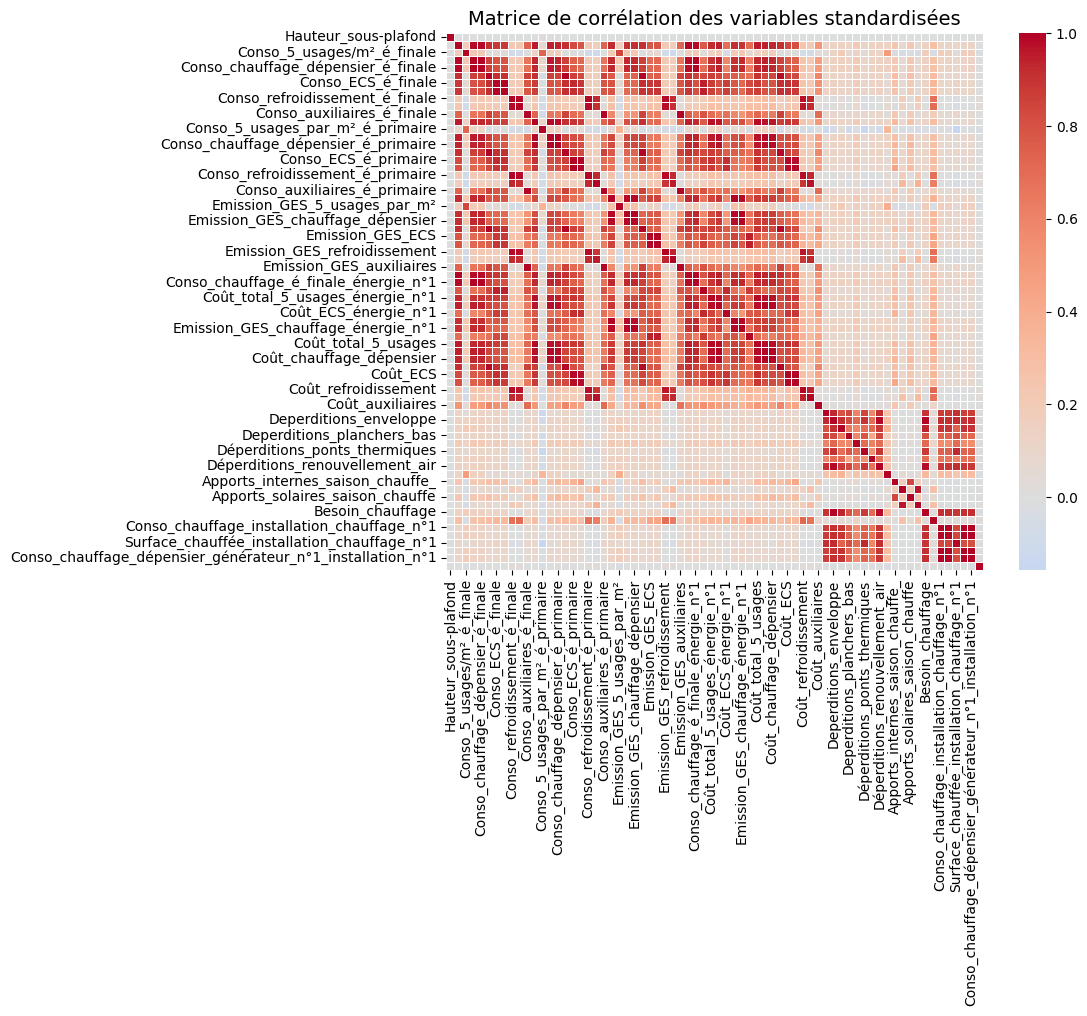

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Taille de la figure
plt.figure(figsize=(12, 10))

# Heatmap de la matrice de corrélation
sns.heatmap(CORR, cmap="coolwarm", center=0, square=True, linewidths=0.5)

# Ajout de titre
plt.title("Matrice de corrélation des variables standardisées", fontsize=14)
plt.tight_layout()
plt.show()


Voici la matrice de corrélation entre mes variables quantitatives standardisées. On y observe plusieurs groupes de variables fortement corrélées entre elles, en particulier les consommations (énergie finale, primaire), les émissions de GES, et les variables de déperdition thermique.

Dans mon heatmap, on observe des blocs rouges indiquant des groupes de variables fortement corrélées — par exemple les consommations et les émissions de GES. 

Ces blocs rouges suggèrent que l’on pourrait réduire le nombre de variables à quelques composantes principales tout en gardant l’essentiel de l'information 

Ce que va nous permettre de faire notre ACP



## 2.b 📐 Calcul des valeurs propres et vecteurs propres

À partir de la matrice de corrélation, on effectue une décomposition en valeurs et vecteurs propres :

- Les **valeurs propres** indiquent la **variance expliquée** par chaque axe principal (ou composante)
- Les **vecteurs propres** sont les **directions** de ces axes dans l’espace des variables

Cela constitue la base de l’ACP, car cela permet de projeter ensuite les variables et les individus.


In [10]:
#Calcul des valeurs propres et vecteurs propres de la matrice CORR 

valeurs_propres, vecteurs_propres = np.linalg.eig(CORR)


In [11]:
print("Valeurs propres") 
print(valeurs_propres)

print("\nVecteurs propres (colonnes)")
print(vecteurs_propres)



Valeurs propres
[3.09443096e+01 1.14662529e+01 7.74252561e+00 3.51038101e+00
 2.34384778e+00 1.82027330e+00 1.64004735e+00 1.47616273e+00
 1.24613876e+00 1.00002595e+00 9.97148615e-01 8.30249398e-01
 7.05368667e-01 6.01194944e-01 5.54675630e-01 4.77184935e-01
 4.22832946e-01 3.15004984e-01 2.82969214e-01 2.29930609e-01
 2.11623243e-01 1.95737928e-01 1.51326158e-01 1.42808739e-01
 1.18975569e-01 9.79706515e-02 9.03273294e-02 8.46646129e-02
 4.97813731e-02 3.92412202e-02 3.84372375e-02 3.12772690e-02
 2.76188784e-02 2.30918720e-02 1.61162680e-02 1.45250234e-02
 1.19178446e-02 1.03961849e-02 9.65385871e-03 7.54797137e-03
 3.52882340e-03 2.63697009e-03 2.54223155e-03 2.19329166e-03
 1.77700554e-03 1.55251105e-03 1.35545882e-03 1.17893639e-03
 1.07395055e-03 6.77545040e-04 4.47837424e-04 3.04969292e-04
 2.61403569e-04 1.89107100e-04 2.02196074e-04 1.36355650e-04
 1.03182836e-04 1.00137024e-04 8.65894820e-05 4.22164928e-05
 2.73647496e-05 6.76367633e-06 5.97935072e-06 2.04109284e-06
 1.82707

### Inertie expliquée

Les valeurs propres permettent de déterminer l'inertie expliquée par chaque axe principale.

A partir de cela nous connaitrons l'information conttenu dans chaque axe

In [12]:

variance_expliquee = valeurs_propres / np.sum(valeurs_propres) * 100

print("Variance expliquée par la première composante :", variance_expliquee[0], "%")
print("Variance expliquée par la deuxième composante :", variance_expliquee[1], "%")
print("Variance expliquée par la Troisieme composante :", variance_expliquee[2], "%")
print("Variance expliquée par la quatrieme composante :", variance_expliquee[3], "%")


Variance expliquée par la première composante : 44.206156523798434 %
Variance expliquée par la deuxième composante : 16.38036123807157 %
Variance expliquée par la Troisieme composante : 11.0607508702092 %
Variance expliquée par la quatrieme composante : 5.014830013394834 %


In [13]:
print("Variances des composantes principales :", variance_expliquee[0] + variance_expliquee[1])

Variances des composantes principales : 60.58651776187


- Nous voyons que le premmier axe contient 44,2 % de l'information
- Le deuxième contient 16,38% de l'information
- J'obtient 60,58 % de l'information total de mes données juste avec les 2 


- Les deux premières composantes expliquent à elles seules une grande partie de la Variance expliquée ce qui justifie leur utilisation pour projeter les individus et analyser la structure globale des logements

Ici, la première composante principale (PC1) explique 44,2 % de la variance totale, ce qui signifie qu’elle capture presque la moitié de l’information contenue dans les données. La deuxième composante (PC2) en explique 16,4 %, portant le cumul à environ 60,6 % pour les deux premières composantes. Les composantes suivantes (PC3 et PC4) ajoutent respectivement 11,1 % et 5,0 %, ce qui est utile mais moins déterminant.

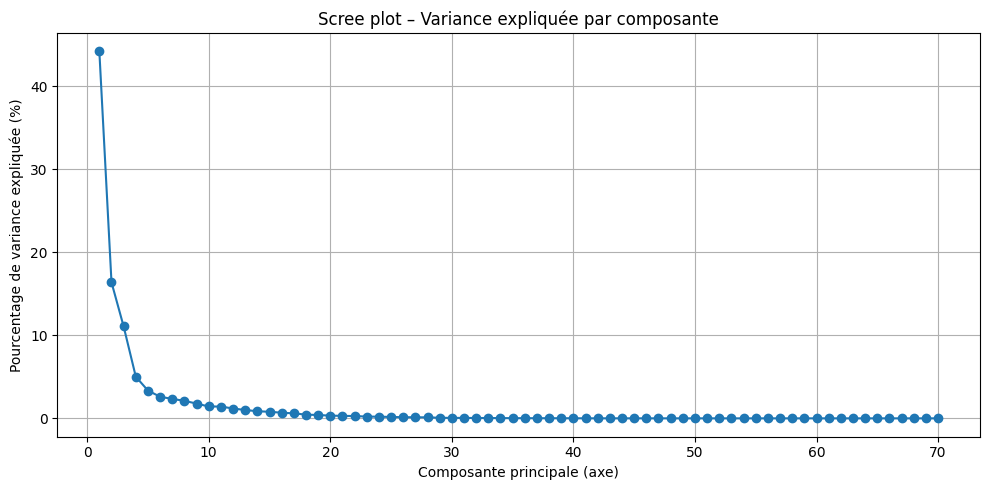

In [14]:
# Graphique de la variance éxpliquée par composante
plt.figure(figsize=(10, 5))
plt.plot(range(1, len( valeurs_propres)+1),  variance_expliquee , marker='o')
plt.xlabel("Composante principale (axe)")
plt.ylabel("Pourcentage de variance expliquée (%)")
plt.title("Scree plot – Variance expliquée par composante")
plt.grid(True)
plt.tight_layout()
plt.show()


 La première composante principale explique une large part de la variance (~44 %), suivie de la deuxième (~16 %), puis une chute rapide. À partir de la 4ème composante, la variance expliquée devient très faible et presque constante, ce qui indique que les composantes au-delà de la 4ème n’apportent que peu d’information supplémentaire.

## Composantes principales

Sont obtenues par la projection des indivdus sur les axes principaux

On sélectionne ici les deux premiers vecteurs propres 

In [15]:
#Création de la matrice de passage 
matrice_passage = vecteurs_propres[:, :2]
matrice_passage[:5]

array([[-1.13329829e-04, -1.71518884e-03],
       [ 1.74503968e-01, -1.04648046e-02],
       [ 2.15940872e-02,  4.98091936e-02],
       [ 1.67875965e-01, -7.58723177e-03],
       [ 1.68473501e-01, -7.57683839e-03]])

In [16]:
#Affichage des résultats
print("\nMatrice de passage")
# print(matrice_passage)


Matrice de passage


In [17]:
composantes_principales = df_standard.dot(matrice_passage)

print("Matrice des deux premières composantes principales :")
print(composantes_principales)


Matrice des deux premières composantes principales :
             0         1
0     0.219647 -1.116451
1    -1.242800 -1.314276
2    -0.462379 -0.324184
3    -1.475480 -1.079927
4    -0.581238 -1.570570
...        ...       ...
8713  0.870316  5.818143
8714  0.128670  1.371259
8715  1.945291 -0.580730
8716 -0.825448 -0.987846
8717 -0.944530  2.430109

[8718 rows x 2 columns]


La matrice des deux premières composantes principales contient les coordonnées des individus projetés sur les axes principaux PC1 et PC2. Chaque ligne représente un individu du jeu de données initial, et les valeurs associées indiquent sa position dans le nouvel espace réduit. Ces coordonnées reflètent la contribution relative de chaque observation par rapport aux axes factoriels extraits de l’ACP.

Par exemple, l’individu 0 a des coordonnées (PC1 = 0.2196, PC2 = -1.1165), ce qui signifie qu’il est légèrement positionné à droite du centre sur PC1, mais fortement en dessous du centre sur PC2. À l’inverse, l’individu 1 présente les valeurs (PC1 = -1.2428, PC2 = -1.3143), ce qui reflète un profil fortement négatif sur les deux axes — suggérant un comportement opposé à la tendance générale résumée par les deux composantes principales.

Certains individus se démarquent particulièrement par leurs valeurs extrêmes. L’individu 8713, par exemple, a des coordonnées (PC1 = 0.8703, PC2 = 5.8181). Sa forte valeur positive sur PC2 indique qu’il est fortement influencé par les variables qui dominent cette composante, et donc très différent de la majorité des autres individus sur cet axe. De même, l’individu 8715, avec des coordonnées (PC1 = 1.9453, PC2 = -0.5807), est fortement positionné sur PC1, ce qui montre une spécificité marquée en lien avec les variables dominantes sur cet axe.

Enfin, des individus comme 3 (PC1 = -1.4755, PC2 = -1.0799) ou 4 (PC1 = -0.5812, PC2 = -1.5706) se situent dans la partie inférieure gauche du plan factoriel, traduisant un profil atypique par rapport aux axes principaux : ils sont à la fois faiblement corrélés aux variables dominantes sur PC1 et inversément liés à celles de PC2.

In [18]:
# Calcul des coordonnées des variables dans le nouveau plan
# On "remet à l'échelle" les vecteurs propres avec les racines des valeurs propres
coord_var = vecteurs_propres * np.sqrt(valeurs_propres)

# Contribution des variables aux axes (en %)
contrib_var_PC1 = (coord_var[:, 0]**2) * 100 / valeurs_propres[0]
contrib_var_PC2 = (coord_var[:, 1]**2) * 100 / valeurs_propres[1]

# Création d'un DataFrame lisible
contrib_df = pd.DataFrame({
    "Variable": df_standard.columns,
    "Contrib_PC1 (%)": contrib_var_PC1.round(2),
    "Contrib_PC2 (%)": contrib_var_PC2.round(2)
})

# Tri des variables les plus contributives
contrib_df.sort_values("Contrib_PC1 (%)", ascending=False).head(10)


,Variable,Contrib_PC1 (%),Contrib_PC2 (%)
40,Coût_total_5_usages,3.07,0.06
1,Conso_5_usages_é_finale,3.05,0.01
31,Conso_5_usages_é_finale_énergie_n°1,3.04,0.01
11,Conso_5_usages_é_primaire,2.97,0.05
34,Coût_total_5_usages_énergie_n°1,2.96,0.07
35,Coût_chauffage_énergie_n°1,2.88,0.04
41,Coût_chauffage,2.87,0.05
4,Conso_chauffage_dépensier_é_finale,2.84,0.01
42,Coût_chauffage_dépensier,2.84,0.05
3,Conso_chauffage_é_finale,2.82,0.01


Nous observons que l’axe 1 est principalement composée par les variables représentant la consommation d’énergie finale et primaire ainsi que les coûts associés, notamment les usages globaux et le chauffage. 

On peut donc l’interpréter comme un axe reflétant l’intensité énergétique du logement — plus on est à droite dans l’espace factoriel, plus le logement consomme et coûte cher en énergie.

Les logements projetés vers la gauche du plan sont donc probablement plus sobres en énergie.

L’analyse des contributions aux deux premières composantes principales de l’ACP révèle que la première composante (PC1) est majoritairement influencée par des variables liées à la consommation et au coût énergétique global des ménages. En effet, les variables Coût_total_5_usages (3.07 %), "Conso_5_usages_é_finale" (3.05 %), Conso_5_usages_é_finale_énergie_n°1 (3.04 %) ou encore Coût_total_5_usages_énergie_n°1 (2.96 %) présentent les contributions les plus élevées à cette composante. Ces résultats indiquent que PC1 résume principalement une dimension de niveau de consommation énergétique et de dépenses associées, particulièrement en lien avec les cinq usages étudiés (chauffage etc.). Ainsi, les individus projetés avec des valeurs élevées sur PC1 sont ceux qui affichent des consommations et des coûts énergétiques importants.

En revanche, la seconde composante principale (PC2) est très faiblement influencée par ces mêmes variables, avec des contributions inférieures à 0.1 %, comme "Coût_chauffage_dépensier" (0.05 %) ou Conso_chauffage_é_finale (0.01 %). Cette faible influence suggère que PC2 capte une dimension différente, probablement liée à des profils énergétiques spécifiques ou atypiques, qui ne sont pas expliqués par le simple volume de consommation ou le montant des dépenses. 


In [19]:
# Affichage des 10 variables les plus contributives à l'axe 2 (PC2).
# On trie la colonne "Contrib_PC2 (%)" par ordre décroissant,
contrib_df.sort_values("Contrib_PC2 (%)", ascending=False).head(10)


,Variable,Contrib_PC1 (%),Contrib_PC2 (%)
50,Deperditions_enveloppe,0.14,8.07
62,Besoin_chauffage,0.13,8.03
56,Déperditions_renouvellement_air,0.12,7.83
65,Conso_chauffage_dépensier_installation_chauffa...,0.09,7.65
64,Conso_chauffage_installation_chauffage_n°1,0.09,7.63
68,Conso_chauffage_dépensier_générateur_n°1_insta...,0.09,7.56
67,Conso_chauffage_générateur_n°1_installation_n°1,0.09,7.53
49,Deperditions_baies_vitrées,0.10,7.20
66,Surface_chauffée_installation_chauffage_n°1,0.08,7.16
51,Déperditions_murs,0.12,6.84


L’axe 2 est structuré majoritairement par des variables liées aux déperditions thermiques et aux besoins en chauffage. Il reflète donc une dimension liée à la qualité de l’enveloppe thermique des logements, à leur capacité à conserver la chaleur, ainsi qu’à l'efficacité du système de chauffage installé.

On peut ainsi interpréter l’axe 2 comme un gradient d’isolation thermique et de performance du chauffage.

La seconde composante principale (PC2), quant à elle, est davantage influencée par des variables liées à la consommation spécifique de chauffage et aux installations associées. Par exemple, des variables telles que Conso_chauffage_dépensier_installation_chauffa (7.65 %), Conso_chauffage_installation_chauffage_n°1 (7.63 %) et "Conso_chauffage_dépensier_générateur_n°1_instal (7.56 %) ont des contributions plus importantes à PC2. Cela indique que PC2 capte une dimension différente, plus spécifiquement liée à la consommation de chauffage dans des installations particulières, notamment celles de type dépensier ou générateur. Les bâtiments ou individus projetés avec des valeurs élevées sur PC2 peuvent donc être caractérisés par des systèmes de chauffage plus énergivores ou moins efficaces.


In [20]:
# Calcul des contributions des individus sur les deux premiers axes
#pour savoir quels logementssont les plus influents sur PC1 et PC2.
data = {
    "Cr1": (composantes_principales.iloc[:, 0]**2) / (valeurs_propres[0] * len(composantes_principales)),
    "Cr2": (composantes_principales.iloc[:, 1]**2) / (valeurs_propres[1] * len(composantes_principales))
}

# Création du DataFrame des contributions
Contribution = pd.DataFrame(data).round(6)

# Affichage
Contribution.head()

,Cr1,Cr2
0,0.000000,0.000012
1,0.000006,0.000017
2,0.000001,0.000001
3,0.000008,0.000012
4,0.000001,0.000025


J’ai calculé la contribution de chaque logement aux deux premiers axes. Cela me permet de repérer les individus les plus influents dans la construction du plan factoriel. 

Les valeurs sont très petites (~0.00001), car elles sont divisées par le nombre total d’individus (8718), pour que la somme des contributions fasse 1 (ou 100 % si on multiplie par 100).

In [31]:
# ➤ Identifier les individus les plus influents sur l'axe PC1

# Étape 1 : Calcul de la contribution moyenne théorique (1 / nombre d'individus)
contrib_moyenne = 1 / len(composantes_principales)

# Étape 2 : Filtrer les individus dont la contribution à PC1 est supérieure à la moyenne
plus_contributeurs_PC1 = Contribution[Contribution["Cr1"] > contrib_moyenne]

# Étape 3 : Trier les plus gros contributeurs à l'axe PC1
plus_contributeurs_PC1_sorted = plus_contributeurs_PC1.sort_values("Cr1", ascending=False)

# Étape 4 : Afficher les 10 premiers
plus_contributeurs_PC1_sorted.head(10)


,Cr1,Cr2
440,0.154800,0.002717
1154,0.056485,0.000621
2360,0.049332,0.000021
6347,0.039528,0.001008
229,0.036066,0.001364
8289,0.031814,0.000030
4802,0.028711,0.000128
8267,0.028032,0.000129
3927,0.026712,0.000123
3077,0.023270,0.000106


J’ai identifié les logements qui contribuent le plus à l’axe principal 1. Il s’agit de cas atypiques, dont les caractéristiques énergétiques (très fortes consommations ou coûts)influence notre espace

Le logement numéro 440, par exemple, représente à lui seul plus de 15 % de l’information portée par cet axe. C’est un cas très atypique.

L'individu 440 se distingue par une contribution de 0.154800, bien supérieure à celle des autres, ce qui suggère qu'il a un impact majeur sur la première composante principale (PC1). Les autres individus, comme ceux numérotés 1154, 2360 et 6347, présentent des contributions plus faibles mais restent au-dessus de la moyenne , ce qui montre qu'ils influencent également de manière significative cette composante. Les contributions varient de 0.023270 pour l'individu 3077 à 0.154800 pour l'individu 440, soulignant ainsi l'écart notable d'influence entre ces individus, avec un leader clair en la personne de l'individu 440, dont l'impact sur PC1 est largement dominant.

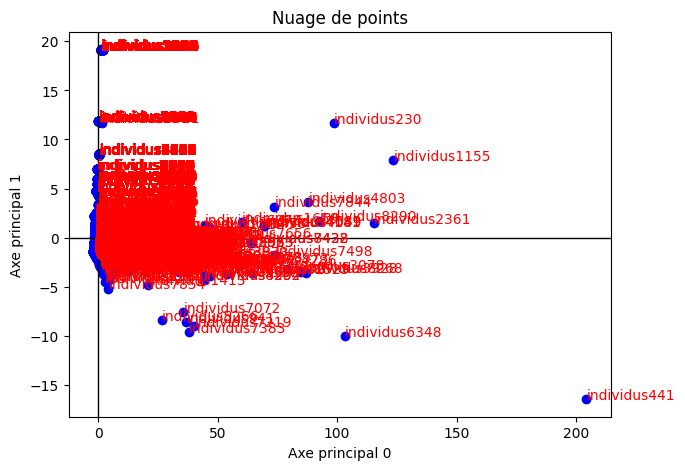

In [32]:
#Création du nuage de points
plt.figure(figsize=(7, 5))
plt.scatter(composantes_principales[0], composantes_principales[1], color='blue')

#Ajouter les annotations des points
for i in range(len(composantes_principales)):
    plt.text(composantes_principales.iloc[i, 0]+0.1, composantes_principales.iloc[i, 1], f'individus{i+1}', 
             fontsize=10, color='red', ha='left')

#Ajouter des lignes au centre
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

#Titres et labels
plt.title("Nuage de points")
plt.xlabel("Axe principal 0")
plt.ylabel("Axe principal 1")
plt.show()
Contribution = pd.DataFrame(data)

# Standardisation correcte si nécessaire :
df_standardized = (Contribution - Contribution.mean()) / Contribution.std()

La projection des individus sur le plan formé par les deux premières composantes principales met en évidence une forte concentration autour de l’origine, traduisant des profils relativement homogènes en termes de consommation et de caractéristiques énergétiques. Néanmoins, certains individus se distinguent nettement. Par exemple, individus441 se situe très à droite sur l’axe 1, ce qui suggère un niveau de consommation énergétique et de dépenses particulièrement élevé, en lien avec les résultats obtenus sur la première composante. D’autres, comme individus230 ou individus1155, sont projetés en hauteur sur l’axe 2, laissant penser qu’ils présentent des spécificités marquées dans leur mode de chauffage ou dans les installations associées. À l’inverse, des individus comme individus7072 ou individus7389 sont projetés plus bas, ce qui  refléte des systèmes de chauffage moins performants ou des comportements énergétiques particuliers.

Au-delà des individus les plus marquants sur l’axe PC1, le graphique permet également d’identifier certains logements qui se distinguent davantage sur l’axe vertical, c’est-à-dire la composante principale 2 (PC2). Cette seconde dimension, précédemment associée aux caractéristiques spécifiques des systèmes de chauffage et à leur efficacité, met en lumière un autre type de différenciation énergétique. Les individus projetés en haut du graphique (points bleus situés au-dessus de l’axe horizontal), bien qu’ils n’aient pas nécessairement des consommations totales élevées, semblent se distinguer par des usages ou équipements de chauffage particuliers.

Ce positionnement suggère que ces ménages  ont recours à des systèmes de chauffage plus énergivores ou moins performants, indépendamment de leur consommation globale. À l’inverse, les individus situés plus bas sur l’axe PC2  représentent des profils équipés de dispositifs plus performants ou affichant des comportements de consommation plus sobres en matière de chauffage. Ces contrastes révèlent l’intérêt d’analyser séparément les deux dimensions : alors que PC1 capte une forme de volume ou d’intensité énergétique globale, PC2 met plutôt en lumière des différences structurelles ou techniques liées aux systèmes de production et d’usage de la chaleur.

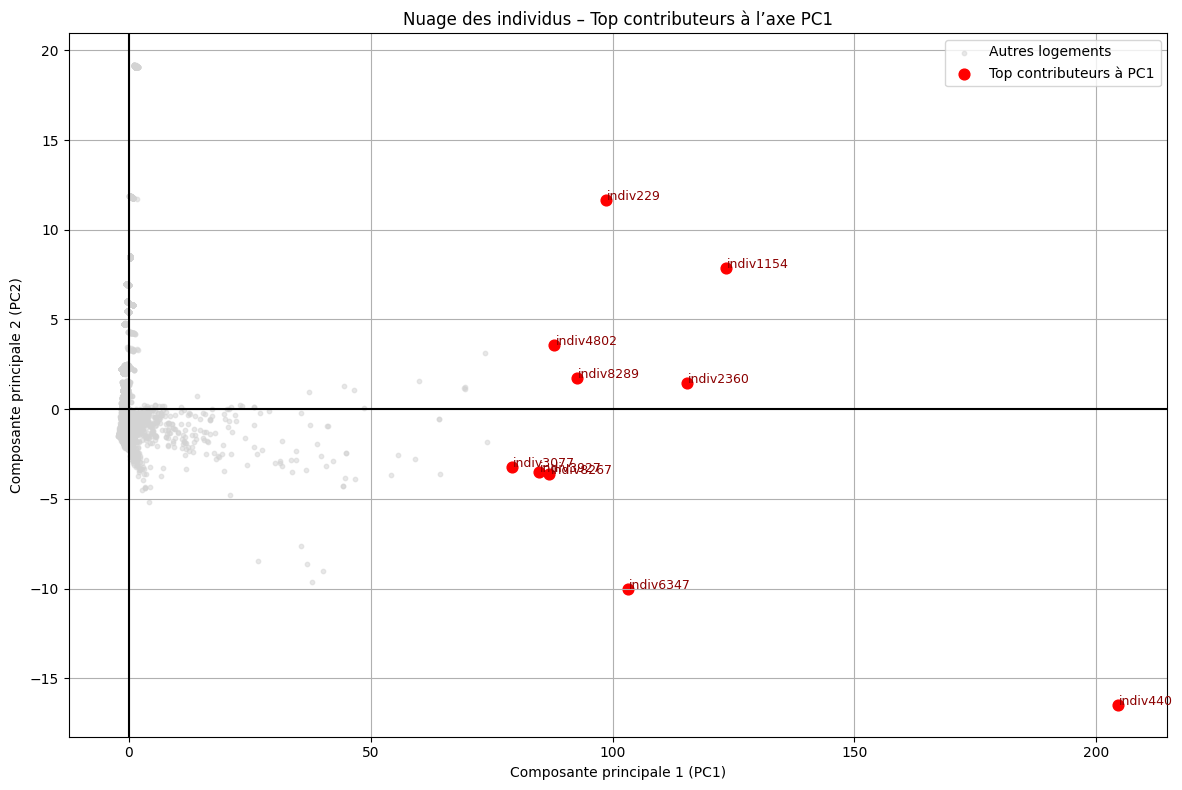

In [33]:
# Liste des indices de logements les plus contributeurs à PC1 
top_contrib_PC1_indices = [440, 1154, 2360, 6347, 229, 8289, 4802, 8267, 3927, 3077]

# ➤ Affichage du nuage de points avec mise en évidence des top contributeurs à PC1
plt.figure(figsize=(12, 8))

# Tous les individus en gris
plt.scatter(composantes_principales.iloc[:, 0],
            composantes_principales.iloc[:, 1],
            color='lightgray', s=10, label='Autres logements', alpha=0.5)

# Meilleurs contributeurs à PC1 en rouge
plt.scatter(composantes_principales.iloc[top_contrib_PC1_indices, 0],
            composantes_principales.iloc[top_contrib_PC1_indices, 1],
            color='red', s=60, label='Top contributeurs à PC1')

# Ajouter les étiquettes
for i in top_contrib_PC1_indices:
    plt.text(composantes_principales.iloc[i, 0] + 0.2,
             composantes_principales.iloc[i, 1],
             f'indiv{i}', fontsize=9, color='darkred')

# Axes et titres
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel("Composante principale 1 (PC1)")
plt.ylabel("Composante principale 2 (PC2)")
plt.title("Nuage des individus – Top contributeurs à l’axe PC1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Sur ce nuage de points, chaque logement est projeté selon les deux premières composantes principales de l’ACP.


En rouge, on voit les logements qui ont la plus forte contribution à l’axe 1. Ils sont très éloignés de l’origine, ce qui confirme leur caractère atypique.


Ces logements influencent fortement l’axe 1, que nous avons interprété comme un axe reflétant l’intensité énergétique et le coût global. Il est donc très probable qu’ils soient parmi les plus énergivores de l’échantillon."

Le nuage des individus ci-dessus met en évidence les principaux contributeurs à l’axe PC1, identifié comme reflétant la dimension de consommation et de dépenses énergétiques globales. Les individus les plus éloignés à droite du nuage comme indiv440, indiv6347 ou encore indiv2360 sont ceux dont les profils énergétiques contribuent le plus à la construction de cette première composante. Cela signifie qu’ils présentent des niveaux de consommation et de coût particulièrement élevés, bien au-delà de la majorité des autres logements représentés en gris. Ces profils extrêmes peuvent traduire des situations particulières : grandes surfaces, équipements très énergivores, ou encore comportements de consommation inhabituels. On note également que certains de ces individus, comme indiv229 ou indiv1154, se distinguent aussi par leur position en hauteur sur l’axe PC2, ce qui peut indiquer des spécificités sur le plan des systèmes de chauffage ou de l’efficacité énergétique.

In [34]:
# ➤ Identifier les individus les plus influents sur l'axe PC2

# Étape 1 : Calcul de la contribution moyenne théorique (déjà fait, mais au cas où)
contrib_moyenne = 1 / len(composantes_principales)

# Étape 2 : Filtrer les individus dont la contribution à PC2 est supérieure à la moyenne
plus_contributeurs_PC2 = Contribution[Contribution["Cr2"] > contrib_moyenne]

# Étape 3 : Trier les plus gros contributeurs à l'axe PC2
plus_contributeurs_PC2_sorted = plus_contributeurs_PC2.sort_values("Cr2", ascending=False)

# Étape 4 : Afficher les 10 premiers
plus_contributeurs_PC2_sorted.head(10)


,Cr1,Cr2
3451,0.000005,0.003687
3334,0.000008,0.003677
1061,0.000004,0.003675
3449,0.000004,0.003675
1549,0.000004,0.003675
3232,0.000004,0.003675
2393,0.000004,0.003675
2895,0.000004,0.003675
3303,0.000004,0.003675
3321,0.000008,0.003674


On voit ici les 10 logements les plus contributeurs à l'axe PC2 . 

Cela signifie qu’ils sont positionnés de façon marquée sur cet axe et qu’ils sont donc fortement liés aux variables qui le définissent, à savoir les déperditions thermiques, les besoins en chauffage, ou encore les caractéristiques du système de chauffage


Ce tableau nous montre que
3451	Ce logement est le plus influent sur PC2


3334 a une forte contribution, ce logement probablement très exposé aux variables liées à l’isolation

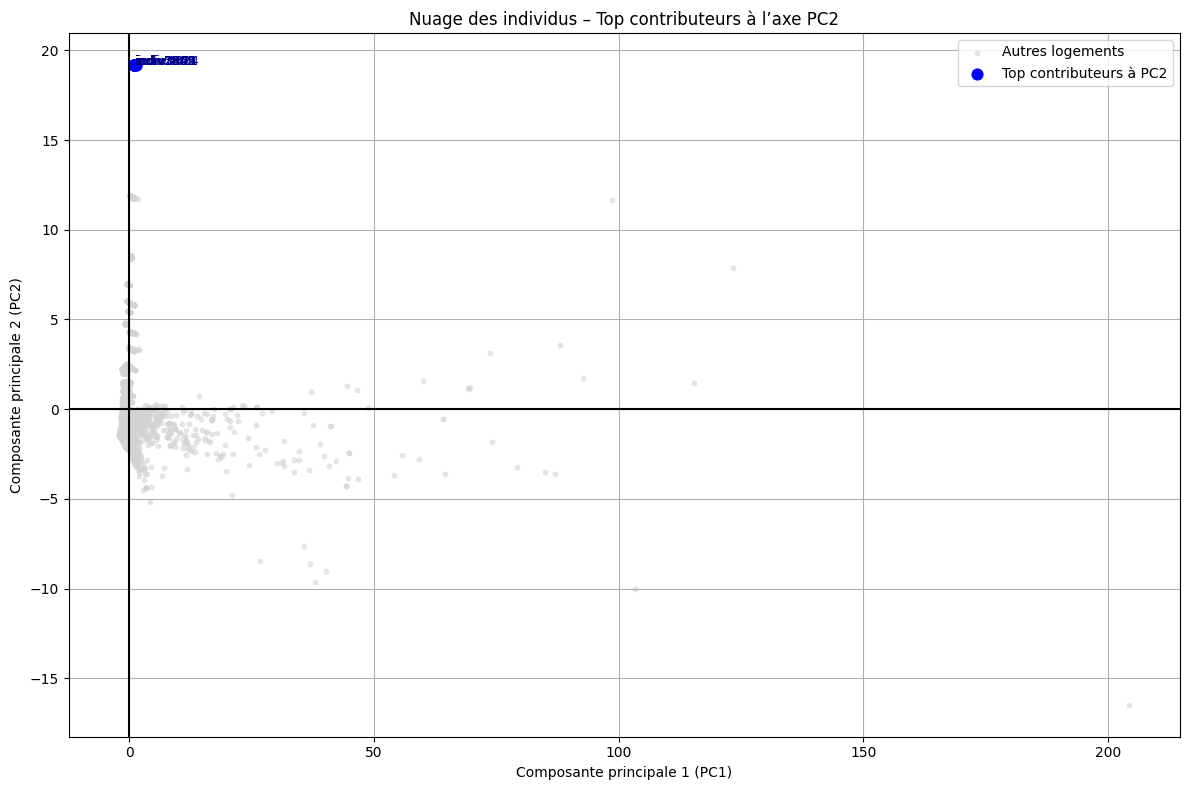

In [35]:
# Liste des indices des top contributeurs à PC2 (à adapter si nécessaire)
top_contrib_PC2_indices = [3451, 3334, 3449, 3303, 3232, 2895, 2393, 1549, 1061, 3321]

# ➤ Affichage du nuage de points avec mise en évidence des top contributeurs à PC2
plt.figure(figsize=(12, 8))

# Tous les individus en gris
plt.scatter(composantes_principales.iloc[:, 0],
            composantes_principales.iloc[:, 1],
            color='lightgray', s=10, label='Autres logements', alpha=0.5)

# Top contributeurs à PC2 en bleu
plt.scatter(composantes_principales.iloc[top_contrib_PC2_indices, 0],
            composantes_principales.iloc[top_contrib_PC2_indices, 1],
            color='blue', s=60, label='Top contributeurs à PC2')

# Ajouter les étiquettes
for i in top_contrib_PC2_indices:
    plt.text(composantes_principales.iloc[i, 0] + 0.2,
             composantes_principales.iloc[i, 1],
             f'indiv{i}', fontsize=9, color='darkblue')

# Axes et titres
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel("Composante principale 1 (PC1)")
plt.ylabel("Composante principale 2 (PC2)")
plt.title("Nuage des individus – Top contributeurs à l’axe PC2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

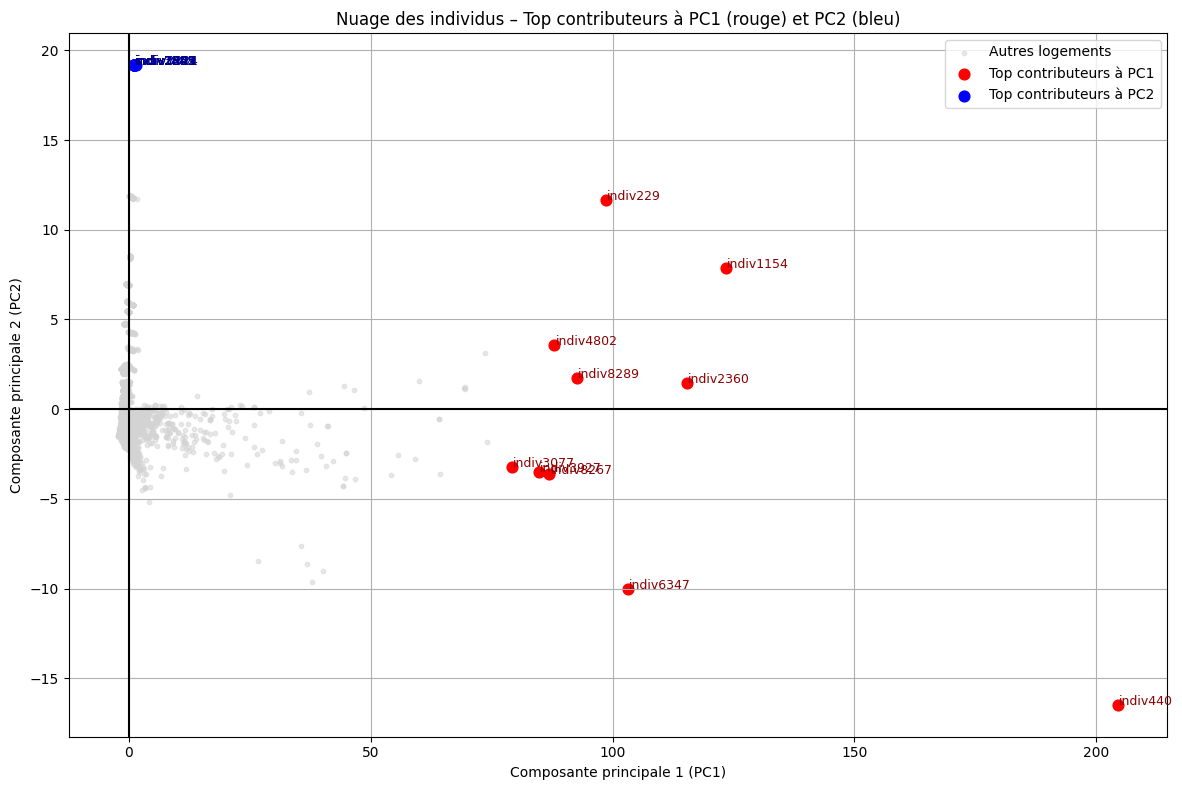

In [36]:
# ➤ Liste des indices des top contributeurs
top_contrib_PC1_indices = [440, 1154, 2360, 6347, 229, 8289, 4802, 8267, 3927, 3077]
top_contrib_PC2_indices = [3451, 3334, 3449, 3303, 3232, 2895, 2393, 1549, 1061, 3321]

# ➤ Affichage du nuage de points combiné
plt.figure(figsize=(12, 8))

# Tous les individus en gris
plt.scatter(composantes_principales.iloc[:, 0],
            composantes_principales.iloc[:, 1],
            color='lightgray', s=10, label='Autres logements', alpha=0.5)

# Top contributeurs à PC1 en rouge
plt.scatter(composantes_principales.iloc[top_contrib_PC1_indices, 0],
            composantes_principales.iloc[top_contrib_PC1_indices, 1],
            color='red', s=60, label='Top contributeurs à PC1')

# Top contributeurs à PC2 en bleu
plt.scatter(composantes_principales.iloc[top_contrib_PC2_indices, 0],
            composantes_principales.iloc[top_contrib_PC2_indices, 1],
            color='blue', s=60, label='Top contributeurs à PC2')

# Étiquettes pour PC1 (rouge)
for i in top_contrib_PC1_indices:
    plt.text(composantes_principales.iloc[i, 0] + 0.2,
             composantes_principales.iloc[i, 1],
             f'indiv{i}', fontsize=9, color='darkred')

# Étiquettes pour PC2 (bleu)
for i in top_contrib_PC2_indices:
    plt.text(composantes_principales.iloc[i, 0] + 0.2,
             composantes_principales.iloc[i, 1],
             f'indiv{i}', fontsize=9, color='darkblue')

# Axes et habillage
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel("Composante principale 1 (PC1)")
plt.ylabel("Composante principale 2 (PC2)")
plt.title("Nuage des individus – Top contributeurs à PC1 (rouge) et PC2 (bleu)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Qualités de représentation.

In [39]:
n = composantes_principales.shape[0]

contribution_individus = pd.DataFrame({
    "Axe 1": (composantes_principales.iloc[:, 0]**2) / (valeurs_propres[0] * n),
    "Axe 2": (composantes_principales.iloc[:, 1]**2) / (valeurs_propres[1] * n)
})

# Normalisation pour que la somme fasse 100%
contribution_individus = contribution_individus.div(contribution_individus.sum()) * 100

# Affichage des premières lignes
print(contribution_individus.head())



      Axe 1     Axe 2
0  0.000018  0.001247
1  0.000573  0.001728
2  0.000079  0.000105
3  0.000807  0.001167
4  0.000125  0.002468


In [40]:
contribution_moyenne = 100 / n
individus_significatifs = contribution_individus[contribution_individus["Axe 1"] > contribution_moyenne]

print(f"Nombre d'individus > contribution moyenne sur Axe 1 : {len(individus_significatifs)}")
individus_significatifs.head()


Nombre d'individus > contribution moyenne sur Axe 1 : 191


,Axe 1,Axe 2
17,0.050433,0.002440
32,0.178196,0.000106
52,0.471098,0.000039
55,0.143226,0.000088
69,0.029176,0.000674


Parmi l’ensemble des individus étudiés, 191 présentent une contribution supérieure à la moyenne sur l’axe 1, ce qui signifie qu’ils participent de manière significative à la construction de cette première composante principale. Cette dernière ayant été associée à une dimension de consommation énergétique globale et de dépenses associées, ces individus apparaissent comme ayant un comportement énergétique plus marqué que la majorité du panel. Ils se distinguent par des niveaux particulièrement élevés de consommation ou de coûts énergétiques, les positionnant en dehors des tendances centrales observées dans l’échantillon.

Parmi eux, certains profils se démarquent très nettement. C’est notamment le cas de l’individu 52, dont la contribution à l’axe 1 s’élève à 0,47 %, un chiffre très supérieur à la moyenne, traduisant un profil particulièrement extrême. De même, les individus 32 et 55 présentent respectivement des contributions de 0,18 % et 0,14 %, confirmant leur rôle dans la structuration de cette dimension de consommation. En revanche, leurs contributions à l’axe 2 restent très faibles, ce qui suggère que leurs particularités énergétiques se concentrent sur le volume global de consommation, et non sur des spécificités liées au chauffage ou aux équipements. À l’opposé, l’individu 69, avec une contribution modérée à PC1 (0,03 %) mais légèrement plus marquée sur PC2, refléte un profil mixte, combinant intensité énergétique globale et caractéristiques techniques spécifiques.

In [144]:
cos2_marque1_axe1 = (composantes_principales.iloc[0, 0] ** 2) / (composantes_principales.iloc[0, :] ** 2).sum()

print("Qualité de représentation de l'individu 1 sur l'Axe 1 :", cos2_marque1_axe1)


Qualité de représentation de l'individu 1 sur l'Axe 1 : 0.037263036642039546


In [136]:
qualite_representation = (composantes_principales.iloc[:, :2] ** 2).div(composantes_principales.pow(2).sum(axis=1), axis=0)

qualite_representation.columns = ["Cos² Axe 1", "Cos² Axe 2"]

print(qualite_representation)


      Cos² Axe 1  Cos² Axe 2
0       0.037263    0.962737
1       0.472069    0.527931
2       0.670435    0.329565
3       0.651169    0.348831
4       0.120462    0.879538
...          ...         ...
8713    0.021886    0.978114
8714    0.008728    0.991272
8715    0.918172    0.081828
8716    0.411153    0.588847
8717    0.131244    0.868756

[8718 rows x 2 columns]


Dans le tableau ci-dessus, on observe par exemple que certains individus, comme l’individu 0, présentent un cos² très élevé sur l’axe 2 (0,96) mais très faible sur l’axe 1 (0,037). Cela signifie que sa position est quasi exclusivement expliquée par la composante principale 2, en lien avec des caractéristiques spécifiques, probablement liées aux systèmes de chauffage ou aux types d’équipements. D’autres, comme les individus 2 et 3, ont des cos² plus équilibrés (autour de 0,65 sur l’axe 1), indiquant qu’ils sont bien représentés sur PC1 mais également partiellement sur PC2, traduisant des profils mixtes. À l’inverse, des individus comme le n°8715 ont un cos² très élevé sur PC1 (0,91) mais très faible sur PC2, ce qui signifie qu’ils sont typiques des profils à forte consommation ou dépenses énergétiques globales.

In [137]:
# Somme des cos² sur les deux premiers axes
cos2_total = qualite_representation["Cos² Axe 1"] + qualite_representation["Cos² Axe 2"]

# On garde ceux avec cos² total > 0.7
indices_bien_representes = cos2_total[cos2_total > 0.7].index


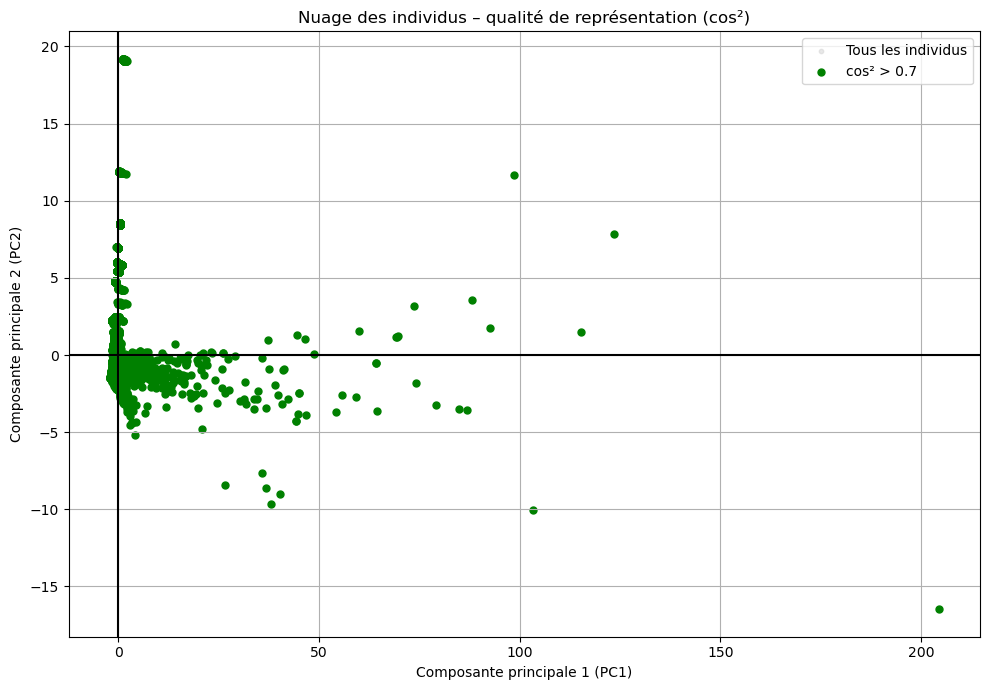

In [138]:
#  Création du nuage de point
plt.figure(figsize=(10, 7))

# Tous les individus en gris
plt.scatter(composantes_principales.iloc[:, 0],
            composantes_principales.iloc[:, 1],
            color='lightgray', s=10, label="Tous les individus", alpha=0.5)

# Les mieux représentés en vert
plt.scatter(composantes_principales.iloc[indices_bien_representes, 0],
            composantes_principales.iloc[indices_bien_representes, 1],
            color='green', s=25, label="cos² > 0.7")

# Axes et style
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel("Composante principale 1 (PC1)")
plt.ylabel("Composante principale 2 (PC2)")
plt.title("Nuage des individus – qualité de représentation (cos²)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Le graphique présente la projection des individus sur le plan formé par les deux premières composantes principales issues de l’analyse en composantes principales (ACP), avec une mise en évidence de ceux dont la qualité de représentation (cos²) dépasse 0,7.

La concentration importante d’individus autour de l’origine indique qu’une grande majorité des observations possèdent une faible contribution aux deux axes principaux, et donc une représentation modérée à faible sur ce plan. Cela est typique lorsque la variance totale est expliquée par un grand nombre de composantes, ou lorsque les individus sont globalement similaires.

En revanche, les individus situés aux extrémités du nuage, particulièrement sur PC1 (certains dépassant même des valeurs de 100 voire 200), sont ceux qui contribuent le plus fortement à la construction des axes factoriels. Leur position excentrée et leur bon cos² (> 0.7) indiquent qu’ils possèdent des profils très spécifiques qui s’écartent notablement de la moyenne. Ces individus méritent une attention particulière car ils peuvent correspondre à des cas atypiques, des valeurs extrêmes, ou des profils caractéristiques dans la population étudiée.

L’axe PC1  structure principalement la dispersion, suggérant qu’il capte une part importante de la variance totale, tandis que PC2 joue un rôle secondaire. Toutefois, certains individus se distinguent également sur PC2, montrant que cette composante révèle une autre dimension d’hétérogénéité au sein des données.

In [146]:
cos2 = (composantes_principales.iloc[:, :2] ** 2).div(composantes_principales.pow(2).sum(axis=1), axis=0)
cos2_total = cos2.sum(axis=1)
indices_bien_representes = cos2_total[cos2_total > 0.7].index


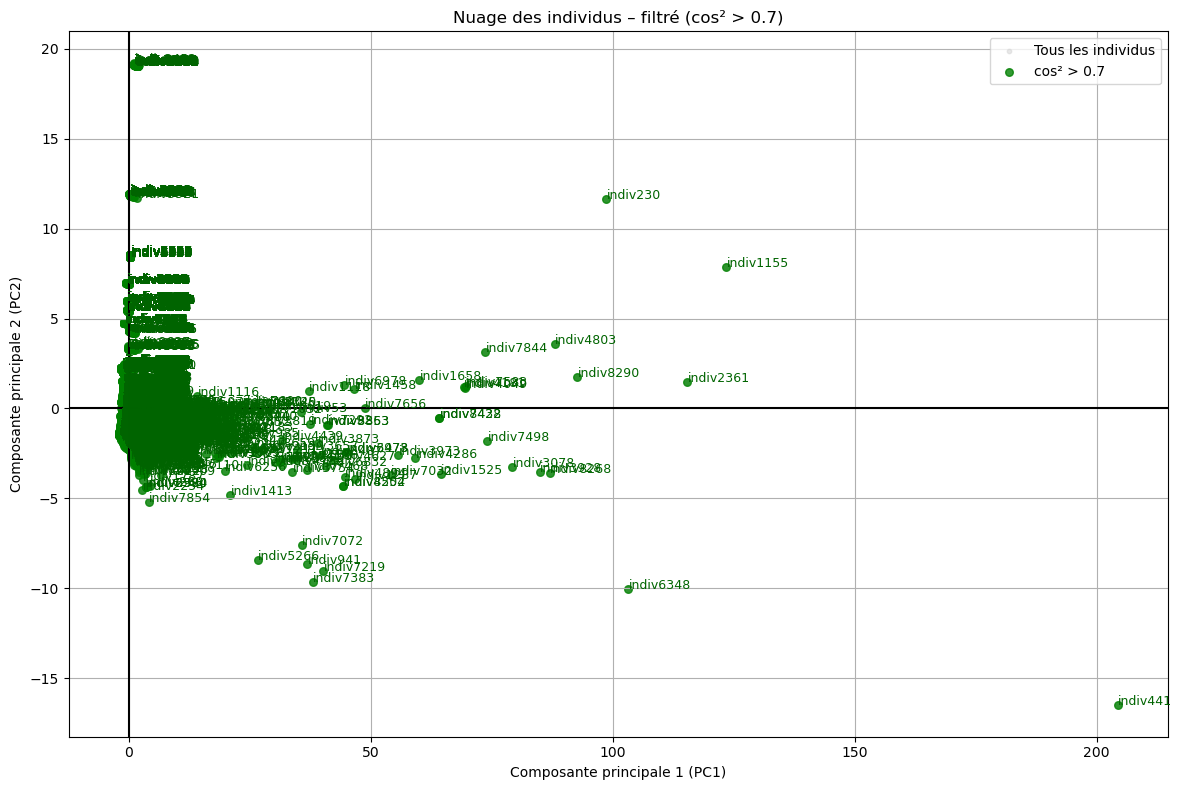

In [147]:
plt.figure(figsize=(12, 8))

# Tous les individus (en gris clair)
plt.scatter(composantes_principales.iloc[:, 0], composantes_principales.iloc[:, 1],
            color='lightgray', s=10, label="Tous les individus", alpha=0.5)

# Individus bien projetés (en vert)
plt.scatter(composantes_principales.iloc[indices_bien_representes, 0],
            composantes_principales.iloc[indices_bien_representes, 1],
            color='green', s=30, label="cos² > 0.7", alpha=0.8)

# Étiquettes  pour les individus bien représentés
for i in indices_bien_representes:
    plt.text(composantes_principales.iloc[i, 0] + 0.1,
             composantes_principales.iloc[i, 1],
             f'indiv{i+1}', fontsize=9, color='darkgreen')

# Axes
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel("Composante principale 1 (PC1)")
plt.ylabel("Composante principale 2 (PC2)")
plt.title("Nuage des individus – filtré (cos² > 0.7)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ce graphique présente la projection des logements dans le plan formé par les deux premiers axes de l’ACP. On y retrouve uniquement les logements bien représentés (cos² > 0.7)

On remarque quelques logements très atypiques comme indiv441, probablement liés à des valeurs extrêmes sur certaines variables, et une forte concentration dans la zone gauche, suggérant une simillarité entre ces logements.

##  Cercle des corrélations

Ce graphique représente la projection des variables dans le plan factoriel formé par les deux premières composantes principales de l’ACP.

- Les flèches indiquent la direction et la contribution des variables.
- Plus une flèche est longue et proche du cercle, mieux la variable est représentée dans le plan.
- Les variables proches les unes des autres sont corrélées.
- Les variables orientées selon PC1 structurent l’axe horizontal (ex : consommation, coût total).
- Celles orientées selon PC2 structurent l’axe vertical (ex : déperditions, besoin de chauffage).

Ce graphique permet de confirmer visuellement l’interprétation des axes et de mieux comprendre la structure globale des données.


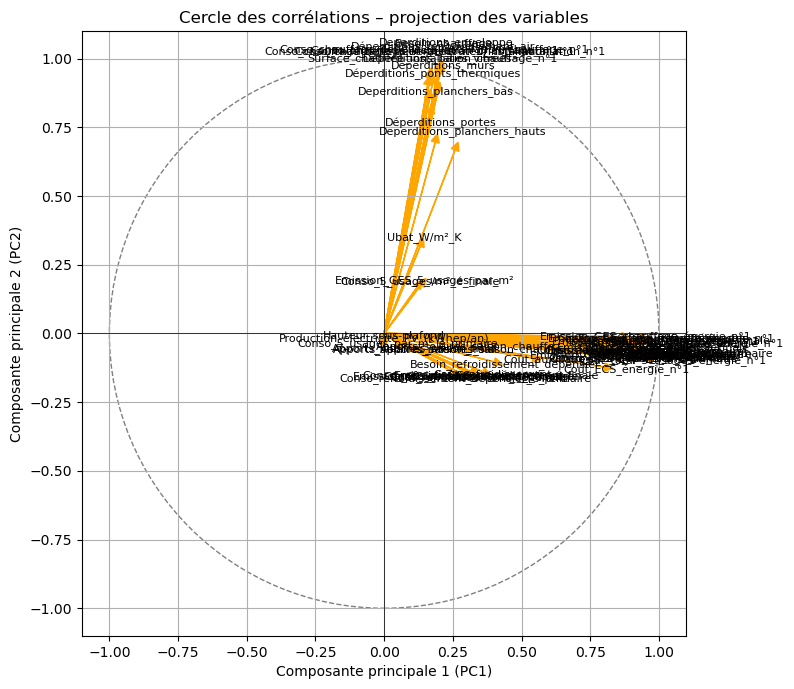

In [176]:

# ➤ Calcul des coordonnées des variables sur les deux premiers axes
coord_var = vecteurs_propres * np.sqrt(valeurs_propres)
x_var = coord_var[:, 0]
y_var = coord_var[:, 1]

# ➤ Affichage du cercle des corrélations
plt.figure(figsize=(8, 8))
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_patch(circle)

# Tracer les flèches pour chaque variable
for i in range(len(x_var)):
    plt.arrow(0, 0, x_var[i], y_var[i],
              head_width=0.03, head_length=0.03,
              fc='orange', ec='orange')
    plt.text(x_var[i]*1.1, y_var[i]*1.1, df_standard.columns[i],
             fontsize=8, ha='center', va='center')

# Habillage du graphique
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Composante principale 1 (PC1)")
plt.ylabel("Composante principale 2 (PC2)")
plt.title("Cercle des corrélations – projection des variables")
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


Le cercle complet contenant 70 variables était trop dense, donc j’ai sélectionné ici les variables les plus représentatives liées à l’énergie et au chauffage, pour analyser leurs relations plus finement.

On voit par exemple que la surface chauffée et la consommation de chauffage sont alignées, ce qui confirme leur corrélation forte

L’analyse du cercle des corrélations met en évidence la structure des relations entre les variables initiales et les deux premières composantes principales issues de l’Analyse en Composantes Principales (ACP). La première composante (PC1) regroupe de manière cohérente un ensemble de variables fortement corrélées entre elles, principalement liées aux consommations énergétiques, aux émissions de gaz à effet de serre, ainsi qu’aux déperditions thermiques. Ces variables présentent des coefficients de corrélation élevés avec PC1, traduisant une contribution importante à l’axe. Cela suggère que cette composante résume l’essentiel de l’information relative à la performance énergétique globale des logements.

En revanche, la deuxième composante (PC2) est caractérisée par un plus faible nombre de variables corrélées de façon significative. Elle capte néanmoins une part de la variabilité associée à certaines spécificités techniques du bâti, notamment les déperditions par les planchers hauts ou bas, ainsi que l’indicateur de qualité thermique global (Ubât). Ces variables, bien que moins dominantes, permettent de distinguer des profils de logements qui, à performance énergétique globale équivalente, présentent des différences dans la manière dont cette performance est atteinte, notamment via l’enveloppe thermique.

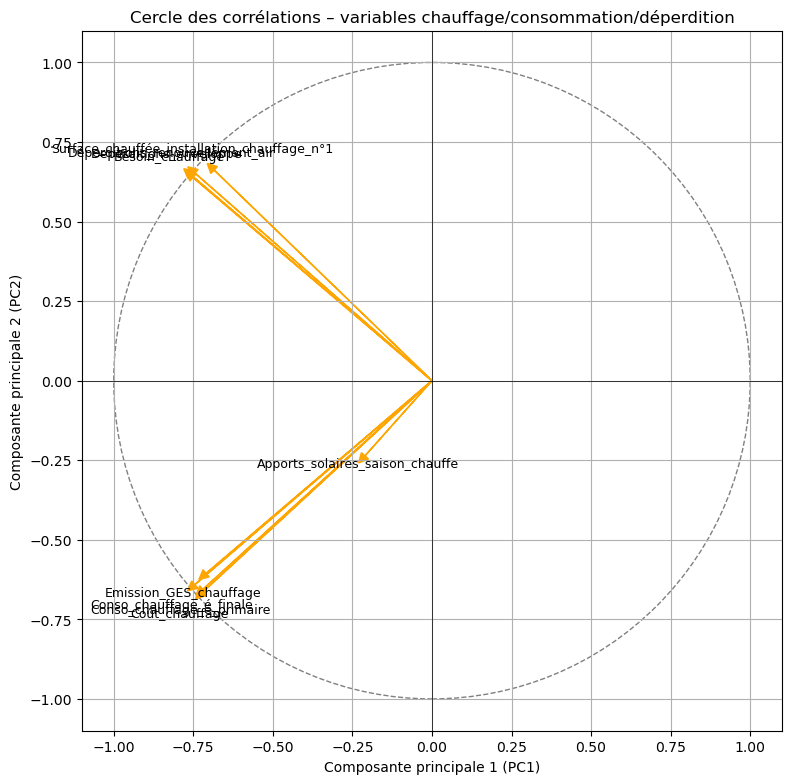

In [174]:
# Noms des variables en français pour l'affichage dans le graphique
noms_variables = [
    "Conso finale chauffage",
    "Conso primaire chauffage",
    "Coût du chauffage",
    "Émissions GES chauffage",
    "Déperditions par l'enveloppe",
    "Déperditions d'air",
    "Apports solaires (hiver)",
    "Besoins de chauffage",
    "Surface chauffée"
]

# ➤ Extraction du sous-ensemble de données
donnees_selectionnees = df_standard[variables_selectionnees]

# ➤ Calcul de la matrice de corrélation et des vecteurs propres
matrice_corr = donnees_selectionnees.corr()
valeurs_propres, vecteurs_propres = np.linalg.eig(matrice_corr)
coordonnees_variables = vecteurs_propres * np.sqrt(valeurs_propres)

# ➤ Coordonnées des variables sur les deux premiers axes
x_variables = coordonnees_variables[:, 0]
y_variables = coordonnees_variables[:, 1]

# ➤ Création du cercle des corrélations
plt.figure(figsize=(8, 8))
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_patch(cercle)

# ➤ Tracer les flèches pour chaque variable
for i in range(len(x_variables)):
    plt.arrow(0, 0, x_variables[i], y_variables[i],
              head_width=0.03, head_length=0.03,
              fc='orange', ec='orange')
    plt.text(x_variables[i]*1.1, y_variables[i]*1.1, noms_variables_fr[i],
             fontsize=9, ha='center', va='center')

# ➤ Habillage du graphique
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Composante principale 1 (PC1)")
plt.ylabel("Composante principale 2 (PC2)")
plt.title("Cercle des corrélations – Lecture simplifiée (énergie & chauffage)")
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()



Le premier groupe de variables est fortement corrélé à la première composante principale (PC1). Il comprend notamment les variables telles que la consommation finale de chauffage, les émissions de gaz à effet de serre liées au chauffage, ainsi que la consommation d’énergie primaire pour le chauffage. Ces variables, orientées de manière très similaire dans l’espace factoriel, traduisent une dimension énergétique globale du chauffage. Leur contribution importante à l’axe PC1 suggère que ce dernier résume principalement les niveaux de consommation et d’impact environnemental associés au système de chauffage des logements.

À l’opposé, un second groupe de variables se distingue par sa projection sur la partie supérieure gauche du cercle, indiquant une contribution plus marquée à la composante PC2. Ce groupe regroupe les besoins de chauffage théoriques, les déperditions par l’enveloppe thermique, ainsi que l’usage réel du chauffage. Ces variables traduisent davantage une logique de performance thermique du bâti, reflétant les pertes d’énergie et l’efficacité des systèmes de chauffage indépendamment de la consommation.

Enfin, la variable « apports solaires saison chauffage » apparaît de manière plus isolée, avec une projection modérée et orientée différemment des autres. Cela suggère que cette variable capture une dimension complémentaire, probablement liée à des apports énergétiques passifs, qui ne sont ni directement corrélés à la consommation ni aux pertes thermiques.

##  Interprétation du cercle des corrélations

J’ai sélectionné ici uniquement les variables liées au **chauffage**, à la **consommation**, aux **pertes thermiques** et à la **surface chauffée** pour mieux lire le cercle.

###  Groupe 1 – Consommation, coût et émissions :
On voit que les flèches de ces variables sont toutes très proches et pointent dans la même direction :
- `Conso_chauffage_é_finale`
- `Conso_chauffage_é_primaire`
- `Coût_chauffage`
- `Emission_GES_chauffage`

 Cela signifie qu’elles sont **fortement corrélées** entre elles.  
Autrement dit, **plus un logement consomme, plus il coûte cher et plus il émet de CO₂**.  
C’est logique et cohérent avec la réalité.

---

###  Groupe 2 – Taille et isolation du logement :
En haut du cercle, on trouve un autre groupe de variables :
- `Déperditions_enveloppe`
- `Déperditions_renouvellement_air`
- `Surface_chauffée_installation_chauffage_n°1`
- `Besoin_chauffage`

 Elles sont aussi alignées, donc corrélées.  
Cela veut dire que **plus un logement est grand ou mal isolé, plus il a besoin de chauffage**.

---

###  Variable un peu isolée – Apports solaires :
- `Apports_solaires_saison_chauffe` est orientée ailleurs, plus à droite du cercle.

 Cela montre qu’elle est **moins liée aux autres variables dans ce plan**, mais elle peut quand même **jouer un rôle dans la réduction des besoins de chauffage**.

---

###  Conclusion :
Ce cercle me permet de **repérer deux grands groupes de variables** :
- Celles qui décrivent **l’intensité énergétique** (conso, coût, GES)
- Celles qui décrivent les **besoins liés à l’enveloppe thermique** (surface, pertes, isolation)

C’est clair, cohérent et bien lié à la logique énergétique d’un logement.


In [169]:
# ➤ Définir les variables explicatives
X = df_standard[[
    'Conso_chauffage_é_finale',
    'Conso_chauffage_é_primaire',
    'Emission_GES_chauffage',
    'Deperditions_enveloppe',
    'Déperditions_renouvellement_air',
    'Apports_solaires_saison_chauffe',
    'Besoin_chauffage',
    'Surface_chauffée_installation_chauffage_n°1'
]]


# ➤ Ajouter une colonne de 1 pour l'intercept (constante)
X_matrix = np.hstack((np.ones((X.shape[0], 1)), X.values))

# ➤ Définir la variable cible
y = df_standard["Coût_chauffage"].values.reshape(-1, 1)

# ➤ Calcul des coefficients : B = (XᵀX)^(-1) Xᵀy
XtX_inv = np.linalg.inv(X_matrix.T @ X_matrix)
beta_hat = XtX_inv @ X_matrix.T @ y

# ➤ Prédictions du modèle
y_pred = X_matrix @ beta_hat

# ➤ Calcul du R² (coefficient de détermination)
ss_res = np.sum((y - y_pred) ** 2)     # somme des carrés des résidus
ss_tot = np.sum((y - y.mean()) ** 2)   # somme des carrés totaux
r2 = 1 - ss_res / ss_tot

# ➤ Calcul du RMSE (erreur quadratique moyenne)
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

# ➤ Préparer le tableau des coefficients
noms_variables = [
    "Constante (intercept)",
    "Conso chauffage (énergie finale)",
    "Conso chauffage (énergie primaire)",
    "Émissions GES chauffage",
    "Déperditions par l’enveloppe",
    "Déperditions air",
    "Apports solaires",
    "Besoin de chauffage",
    "Surface chauffée"
]

coefs_df = pd.DataFrame({
    "Variable explicative": noms_variables,
    "Coefficient": beta_hat.flatten().round(4)
})

# ➤ Afficher les coefficients
print("Coefficients du modèle de régression :")
display(coefs_df)

# ➤ Afficher les indicateurs globaux
print("\n Indicateurs de performance :")
print(f"R² : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")

Coefficients du modèle de régression :


,Variable explicative,Coefficient
0,Constante (intercept),-0.0000
1,Conso chauffage (énergie finale),-0.4728
2,Conso chauffage (énergie primaire),1.1008
3,Émissions GES chauffage,0.3945
4,Déperditions par l’enveloppe,0.0895
5,Déperditions air,0.0365
6,Apports solaires,0.0054
7,Besoin de chauffage,-0.1178
8,Surface chauffée,-0.0141



 Indicateurs de performance :
R² : 0.9834
RMSE : 0.1289


# 4. Modélisation par régression

##  Régression linéaire multiple

Dans cette partie, j’ai effectué une régression linéaire multiple **en utilisant uniquement NumPy**, sans bibliothèque de machine learning. Cela me permet de mieux comprendre **le fonctionnement mathématique du modèle**.

###  Objectif :
Expliquer la variable **Coût de chauffage** à partir de plusieurs variables explicatives liées à l’énergie et aux caractéristiques thermiques du logement.

###  Variables explicatives utilisées :
- Conso chauffage (énergie finale)
- Conso chauffage (énergie primaire)
- Émissions GES chauffage
- Déperditions par l’enveloppe
- Déperditions air
- Apports solaires
- Besoin de chauffage
- Surface chauffée

###  Méthode :
J’utilise la formule matricielle :
\[
\hat{\beta} = (X^T X)^{-1} X^T y
\]
où `X` est la matrice des variables explicatives (avec une constante), et `y` est le vecteur cible.

###  Résultats :
- **R² = 0.9834** → le modèle explique **98,3 % de la variance du coût de chauffage**
- **RMSE = 0.1289** → erreur moyenne faible, prédictions précises

###  Interprétation :
Les coefficients obtenus permettent de voir **l’impact de chaque variable sur le coût de chauffage**.  
Le modèle est très performant et confirme les résultats vus dans l’ACP :  
→ **plus un logement consomme, est grand ou mal isolé, plus il coûte cher à chauffer**.

Cette approche mathématique directe complète bien l’analyse exploratoire.


## Conclusion générale de l’analyse énergétique des logements

Dans ce projet, j’ai analysé un ensemble de données techniques sur les logements à travers une **analyse en composantes principales (ACP)**, suivie d’une **régression linéaire multiple**.


L’ACP m’a permis de repérer deux grands types de logements :
- Ceux qui consomment beaucoup, coûtent cher et polluent (PC1)
- Ceux qui sont mal isolés, avec de fortes pertes et un fort besoin de chauffage (PC2)

La régression confirme que le **coût de chauffage** est surtout lié à :
- La consommation d’énergie
- Les déperditions thermiques
- La surface chauffée

###  Recommandations :
- **Prioriser l’isolation thermique** des logements avec de fortes pertes
- **Améliorer les systèmes de chauffage** dans les logements très consommateurs
- **Valoriser les apports solaires** pour compenser une partie des besoins




# 🧰 Fonctions pour la démonstration interactive

##  Projection de variables sur un plan factoriel (ACP)

Cette fonction me permet de projeter **un sous-ensemble de variables** sur un plan de l’analyse en composantes principales, selon les axes choisis.

###  Objectif :
Visualiser les relations entre variables (corrélations) dans un espace réduit à 2 dimensions, pour faciliter l’interprétation.

###  Comment ça marche :
- On calcule la **matrice de corrélation** des variables sélectionnées
- On applique une **ACP** sur cette matrice
- On affiche la **projection des vecteurs propres** (variables) sur le plan formé par deux axes principaux

###  Exemple :
```python
projeter_variables_colonnes([
    'Conso_chauffage_é_finale',
    'Besoin_chauffage',
    'Surface_chauffée_installation_chauffage_n°1'
], axe1=1, axe2=2)


In [178]:
def projeter_variables_colonnes(noms_colonnes, axe1=1, axe2=2, df_source=df_standard):
    """
    Projette les variables spécifiées sur le plan factoriel défini par les axes donnés.

    Paramètres :
    - noms_colonnes : liste des noms de colonnes à projeter (ex : ['Conso_chauffage_é_finale', 'Surface_chauffée'])
    - axe1, axe2 : numéros des axes à utiliser pour la projection (1 pour PC1, 2 pour PC2, etc.)
    - df_source : DataFrame standardisé contenant les données numériques

    Affiche un cercle des corrélations avec les flèches représentant les variables.
    """

    # Sélection du sous-ensemble des variables
    df_variables = df_source[noms_colonnes]

    # Calcul de la matrice de corrélation
    matrice_corr = df_variables.corr()

    # Décomposition en valeurs et vecteurs propres (ACP)
    valeurs_propres, vecteurs_propres = np.linalg.eig(matrice_corr)
    coordonnees_variables = vecteurs_propres * np.sqrt(valeurs_propres)

    # Projection sur les axes sélectionnés (indexés à partir de 0)
    x = coordonnees_variables[:, axe1 - 1]
    y = coordonnees_variables[:, axe2 - 1]

    # Création du cercle
    plt.figure(figsize=(7, 7))
    cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
    plt.gca().add_patch(cercle)

    # Tracer les vecteurs (flèches)
    for i in range(len(noms_colonnes)):
        plt.arrow(0, 0, x[i], y[i],
                  head_width=0.03, head_length=0.03,
                  fc='orange', ec='orange')
        plt.text(x[i]*1.12, y[i]*1.12, noms_colonnes[i],
                 fontsize=10, ha='center', va='center')

    # Mise en forme du graphique
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlabel(f"Axe {axe1}")
    plt.ylabel(f"Axe {axe2}")
    plt.title("Projection des variables sur le plan factoriel")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()


##  Fonction – Régression linéaire multiple (sans sklearn)

Cette fonction permet de réaliser une **régression linéaire multiple** en utilisant la formule matricielle (sans librairie externe).

###  Objectif :
Expliquer une **variable cible** à partir de plusieurs **variables explicatives**, et mesurer la qualité du modèle.

###  Fonction appelée :
```python
regression_multiple(
    nom_variable_cible="Coût_chauffage",
    liste_variables_explicatives=[
        "Conso_chauffage_é_finale",
        "Emission_GES_chauffage",
        "Déperditions_enveloppe",
        "Surface_chauffée_installation_chauffage_n°1"
    ]
)


In [179]:
def regression_multiple(nom_variable_cible, liste_variables_explicatives, df_source=df_standard):
    """
    Réalise une régression linéaire multiple (sans sklearn) sur un DataFrame standardisé.

    Paramètres :
    - nom_variable_cible : str, nom de la variable à prédire
    - liste_variables_explicatives : list, noms des variables explicatives
    - df_source : DataFrame contenant les données standardisées

    Affiche : coefficients, R², RMSE
    """

    # ➤ Création des matrices
    X = df_source[liste_variables_explicatives]
    y = df_source[nom_variable_cible].values.reshape(-1, 1)

    # ➤ Ajout de l’intercept
    X_matrix = np.hstack((np.ones((X.shape[0], 1)), X.values))

    # ➤ Calcul des coefficients via la formule matricielle
    XtX_inv = np.linalg.inv(X_matrix.T @ X_matrix)
    beta_hat = XtX_inv @ X_matrix.T @ y

    # ➤ Prédictions
    y_pred = X_matrix @ beta_hat

    # ➤ Évaluation : R² et RMSE
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))

    # ➤ Affichage des résultats
    print(" Régression multiple")
    print("Variable cible :", nom_variable_cible)
    print("Variables explicatives :", liste_variables_explicatives)
    print()

    noms_variables = ["Constante"] + liste_variables_explicatives
    for nom, coef in zip(noms_variables, beta_hat.flatten()):
        print(f"{nom} : {coef:.4f}")

    print(f"\nR² : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
